In [1]:
"""
VGG16を転移学習する

新しい用途（例えば犬と猫の2種類のうち、どちらであるかを分類したい場合など）に対応させるために、
転移学習を行います。

手順は以下の通りです。順に説明していきます。

・VGG16の全結合層以外の取得
・独自の全結合層の追加
・独自の全結合層部分のみの学習
・予測

"""

'\nVGG16を転移学習する\n\n新しい用途（例えば犬と猫の2種類のうち、どちらであるかを分類したい場合など）に対応させるために、\n転移学習を行います。\n\n手順は以下の通りです。順に説明していきます。\n\n・VGG16の全結合層以外の取得\n・独自の全結合層の追加\n・独自の全結合層部分のみの学習\n・予測\n\n'

In [2]:
"""
転移学習用の画像データ準備

Google Colaboratoryで転移学習のソースコードを作成します。
そのため、Google ColaboratoryからアクセスしやすいGoogleドライブに学習用の画像データを格納します。

画像データの準備の流れは、以下の通りです。

・Googleドライブ上での画像データ格納用フォルダの作成
まずは、マイドライブの最上位の階層に、学習データ保管用の「data_train」と、
テストデータ保管用の「data_test」という名称のフォルダを作成します。
作成した「data_train」フォルダの内部に、「dog」と「cat」という名称のフォルダを作成します。
同様に「data_test」フォルダ内部にも、「dog」と「cat」という名称のフォルダを作成します。

・画像データの取得
次に、犬と猫の画像データを用意します。MicrosoftのサイトのDawnloadボタンから、
https://www.microsoft.com/en-us/download/details.aspx?id=54765
「kagglecatsanddogs_5340.zip」ファイルをダウンロードできます。

・Googleドライブへのアップロード
ダウンロードした画像	　　　　　　　　　　　　　格納先
Dogフォルダの0.jpg～255.jpgの計256ファイル	マイドライブ > data_train > dog
Catフォルダの0.jpg～255.jpgの計256ファイル	マイドライブ > data_train > cat
Dogフォルダの256.jpg～319.jpgの計64ファイル	マイドライブ > data_test > dog
Catフォルダの256.jpg～319.jpgの計64ファイル	マイドライブ > data_test > cat
"""

'\n転移学習用の画像データ準備\n\nGoogle Colaboratoryで転移学習のソースコードを作成します。\nそのため、Google ColaboratoryからアクセスしやすいGoogleドライブに学習用の画像データを格納します。\n\n画像データの準備の流れは、以下の通りです。\n\n・Googleドライブ上での画像データ格納用フォルダの作成\nまずは、マイドライブの最上位の階層に、学習データ保管用の「data_train」と、\nテストデータ保管用の「data_test」という名称のフォルダを作成します。\n作成した「data_train」フォルダの内部に、「dog」と「cat」という名称のフォルダを作成します。\n同様に「data_test」フォルダ内部にも、「dog」と「cat」という名称のフォルダを作成します。\n\n・画像データの取得\n次に、犬と猫の画像データを用意します。MicrosoftのサイトのDawnloadボタンから、\nhttps://www.microsoft.com/en-us/download/details.aspx?id=54765\n「kagglecatsanddogs_5340.zip」ファイルをダウンロードできます。\n\n・Googleドライブへのアップロード\nダウンロードした画像\t\u3000\u3000\u3000\u3000\u3000\u3000\u3000\u3000\u3000\u3000\u3000\u3000\u3000格納先\nDogフォルダの0.jpg～255.jpgの計256ファイル\tマイドライブ > data_train > dog\nCatフォルダの0.jpg～255.jpgの計256ファイル\tマイドライブ > data_train > cat\nDogフォルダの256.jpg～319.jpgの計64ファイル\tマイドライブ > data_test > dog\nCatフォルダの256.jpg～319.jpgの計64ファイル\tマイドライブ > data_test > cat\n'

In [3]:
"""
実験の再現性を高めるために、乱数を固定します。
Kerasのutilsモジュールのset_random_seed関数によって、
Pythonのrandomモジュール、Numpyのrandomモジュール、TensorFlowのrandomモジュールで
発生する乱数を固定可能です。
"""
from tensorflow.keras import utils
utils.set_random_seed(0)

In [4]:
"""
Googleドライブにアップロードした犬と猫の画像データを読み込むために、
KerasのImageDataGeneratorというクラスを使用します。

ここでは、ImageDataGeneratorのセットアップ方法について解説します。

ImageDataGeneratorとは
ImageDataGeneratorは、特定のフォルダに格納されている画像データを、
前処理しながら、予測モデルに流し込む機能を提供します。

まずはImageDataGeneratorをインポートします。
"""
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
"""
ImageDataGeneratorのインスタンスを作成します。
パラメータを指定することで、画像データの加工や複製方法の設定が可能です。
今回は、以下のパラメータを指定します。

パラメータ	説明
rescale	画像データが持つピクセル値をスケーリングできます。今回は、1/255を指定します。
validation_split	学習データの一部を、バリデーションデータとして使用する割合を指定します。今回は、25%を指定します。

※補足：その他、以下のようなパラメータの指定も可能です。主に学習データの複製に利用するパラメータです。

パラメータ	説明
rotation_range	指定した範囲内で、画像をランダムに回転させます。
width_shift_range / height_shift_range	指定した範囲内で、画像を水平または垂直にシフトさせます。
zoom_range	指定した範囲内で、画像をランダムにズームさせます。
"""
datagen = ImageDataGenerator(rescale=1/255, validation_split=0.25)

In [6]:
#画像データの流し込み方法の設定
"""
次に、ジェネレータを作成します。
ジェネレータとは、一定数の画像データを、繰り返し予測モデルへ流し込む機能を持ったオブジェクトです。

flow_from_directoryメソッドで、ジェネレータを作成できます。
第1引数に、流し込みたい画像の格納先フォルダを指定します。また、以下のパラメータも指定可能です。

subset：「training」または「validation」を指定します。
これは、ImageDataGeneratorのインスタンス化の際に、validation_splitパラメータで、
バリデーションデータを確保した場合にのみ利用するものです。

target_size：画像をリサイズするためのパラメータです。今回は、(256, 256)と指定します。
これによって、流し込み時に画像が256ピクセル×256ピクセルにリサイズされます。

batch_size：一度に予測モデルに流し込む画像データの数を指定します。今回は64を指定します。


まずは、学習データのジェネレータを作成します。
"""
train_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/data_train',
    subset='training',
    target_size=(256, 256),
    batch_size=64)

Found 384 images belonging to 2 classes.


In [7]:
"""
実行結果として「Found 384 images（384ファイル見つかった）」と表示されました。
これは、data_trainフォルダに含まれる画像514枚（犬256枚＋猫256枚）のうち
75%（25%はバリデーションデータ）である384枚が検知されたことを意味します。

また「belonging to 2 classes（2クラスに属する）」ことも表示されています。
これは、犬と猫の2つのカテゴリが認識されていることを意味します。
前章の画像データの準備の際、data_trainフォルダに、dogフォルダとcatフォルダを作成して、
それぞれに画像を格納しました。このフォルダ構成によって、
ImageDataGeneratorが自動的にどの画像が犬で、どの画像が猫なのかを認識するようになります。

なお、転移学習において、犬と猫のカテゴリは、数値ラベルとして表現されます。
どちらのカテゴリが、どの数値ラベルであるかは、class_indices属性で確認できます。
"""
train_generator.class_indices

{'cat': 0, 'dog': 1}

In [8]:
"""
この結果から、猫は数値ラベル0、犬は数値ラベル1で表現されることを確認できました。
"""

'\nこの結果から、猫は数値ラベル0、犬は数値ラベル1で表現されることを確認できました。\n'

In [9]:
"""
学習データのジェネレータと同様に、バリデーションデータのジェネレータも作成します。
"""
val_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/data_train',
    subset='validation',
    target_size=(256, 256),
    batch_size=64
)

Found 128 images belonging to 2 classes.


In [10]:
"""
続いて、テストデータのジェネレータも作成しましす。

なお、テストデータは、「training」と「validation」の区分がないため、
subsetパラメータの指定は不要です。
"""
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/data_test',
    target_size=(256, 256),
    batch_size=64
)

Found 128 images belonging to 2 classes.


In [11]:
"""
以上で、学習データのセットアップは完了です。
"""

'\n以上で、学習データのセットアップは完了です。\n'

In [12]:
"""
次に、VGG16の全結合層を取り除くため、
include_top=Falseオプションを指定してVGG16を取得します。

また、input_shape=(256, 256, 3)も指定します。
これによって、VGG16へインプットできる画像のサイズを、
ジェネレータ作成の際に設定した画像サイズ「256ピクセル×256ピクセル」に揃えることが可能です。
"""
from tensorflow.keras.applications.vgg16 import VGG16
vgg16_without_fc = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

#以上で、VGG16の全結合層以外の取得は完了です。

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [13]:
"""
得したVGG16の構造を確認するために、summary()メソッドを使って可視化します。
前章でVGG16を取得したときには存在した、最後の全結合層が除外されていることが確認できます。
"""
vgg16_without_fc.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
"""
次に、VGG16をSequentialモデルに変換します。
Sequentialモデルとは、Sequentialクラスを用いて予測モデルを定義する形式です。
取得したVGG16は、Functional APIという異なる形式でモデルの構造が定義されています。

VGG16をSequentialモデルに変換する理由は、
独自の層を簡潔に追加できるようにするためです。

まずSequentialクラスをインスタンス化します。
次に、VGG16の各層を1つずつ、addメソッドで追加していきます。
これにより、VGG16モデルを、Sequentialモデルへ変換できます。
"""
from tensorflow.keras.models import Sequential
model = Sequential()
for layer in vgg16_without_fc.layers:
  model.add(layer)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
"""
10 VGG16のパラメータ凍結

次に、VGG16由来の層のパラメータを変更しないようにするため、
各層のtrainable属性をFalseに設定します。

この設定によって、学習をしてもVGG16由来の層のパラメータはそのままの値で保持され、
後続プロセスで結合する独自の全結合層のパラメータのみが、学習の対象となります。

それでは、各層のtrainable属性をFalseに設定し、パラメータを凍結します。
"""
for layer in model.layers:
  layer.trainable = False

In [17]:
"""
次に、全結合層を取り除いたVGG16に、犬と猫を分類するための独自の全結合層を追加します。
以下のステップで追加します。

1.全結合層を取り除いたVGG16からの出力されるデータを、
　Flattenクラスを使用して1次元に変換します。

2.独自の全結合層を隠れ層として追加します。
　今回はノード数を256、活性化関数をReLUとします。
　ノード数には明確な推奨値がなく、後続の学習や評価プロセスの結果を見ながら、試行錯誤して決定する項目です。

3.独自の全結合層を出力層として追加します。
　犬と猫の分類をするため、ノード数は2、活性化関数をソフトマックス関数とします。
"""
from tensorflow.keras.layers import Flatten, Dense
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(2, activation='softmax'))

In [18]:
"""
VGG16と独自の全結合層を結合したモデルの構造を確認します。
"""
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,104,066 (88.14 MB)

 Trainable params: 8,389,378 (32.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
"""
1次元データへの変更プロセスであるFlattenと、2つの全結合層が追加されていることを確認できました。

さらに、注目してほしいのが、Total param（全パラメータ数）23,104,066のうち、
14,714,688がNon-trainnable param（学習しないパラメータ）となっている部分です。
VGG16のパラメータ凍結で実施した処理が、反映されていることを示しています。

また、追加した独自の全結合層のパラメータの合計（8,388,864+514）と、
学習対象のパラメータを意味するTrainable paramsの値が、
共に8,389,378で一致していることも確認できます。
つまり、新しく追加した全結合層のみが学習対象であることが示されています。
"""

'\n1次元データへの変更プロセスであるFlattenと、2つの全結合層が追加されていることを確認できました。\n\nさらに、注目してほしいのが、Total param（全パラメータ数）23,104,066のうち、\n14,714,688がNon-trainnable param（学習しないパラメータ）となっている部分です。\nVGG16のパラメータ凍結で実施した処理が、反映されていることを示しています。\n\nまた、追加した独自の全結合層のパラメータの合計（8,388,864+514）と、\n学習対象のパラメータを意味するTrainable paramsの値が、\n共に8,389,378で一致していることも確認できます。\nつまり、新しく追加した全結合層のみが学習対象であることが示されています。\n'

In [20]:
"""
次は、誤差関数、最適化方法、評価指標の設定をします。

誤差関数として二値交差エントロピー誤差（Binary Cross-Entropy Error）を使用します。
二値交差エントロピー誤差は、
2つのカテゴリ（今回は犬と猫）を分類する際に一般的に利用される誤差関数です。
compileメソッドの引数で、loss='binary_crossentropy'と指定すれば適用されます。

また、最適化手法としてAdamを、評価指標として正解率（accuracy）を指定します。
"""
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [21]:
"""
14 学習

学習データとバリデーションデータを使って予測モデルを学習させます。
この際に、以下の引数を指定します。

train_generator：学習データを供給するデータジェネレータを指定します。
これにより、モデルに対して学習データの流し込みが行われます。

validation_data=val_generator：バリデーションデータとして、
val_generatorを指定します。
これによって、学習中にバリデーションデータによる損失関数と正解率の推移をモニタリングできます。

epochs：学習をするエポック数を指定します。今回は5エポックで学習します。

なお、バッチサイズはジェネレータ作成時に設定した64が適用されます。
"""
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 165s 24s/step - accuracy: 0.5454 - loss: 2.9490 - val_accuracy: 0.8203 - val_loss: 0.9059
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 635ms/step - accuracy: 0.8020 - loss: 0.6979 - val_accuracy: 0.9141 - val_loss: 0.4676
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 636ms/step - accuracy: 0.9234 - loss: 0.2829 - val_accuracy: 0.9375 - val_loss: 0.1618
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 665ms/step - accuracy: 0.9708 - loss: 0.1122 - val_accuracy: 0.9375 - val_loss: 0.2279
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 650ms/step - accuracy: 0.9964 - loss: 0.0602 - val_accuracy: 0.9531 - val_loss: 0.1291


In [ ]:
"""
以上で、予測モデルの学習は完了です。
"""

<Axes: >

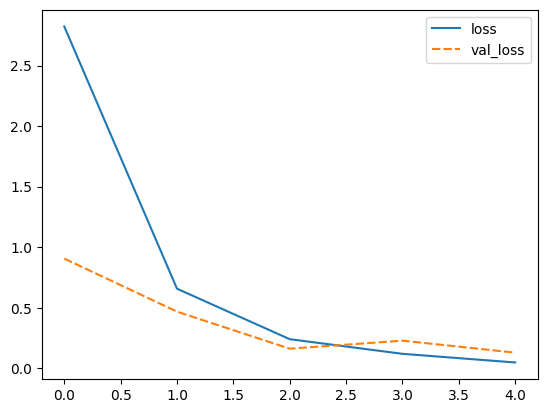

In [22]:
"""
学習履歴の可視化

次に、学習過程での正解率と損失の変化を可視化し、過学習や学習不足を確認します。

fit関数の戻り値であるHistoryオブジェクトのhistory属性に、
学習履歴の推移が格納されています。
DataFrameに変換し、seabornのlineplotメソッドを利用して、
損失関数（loss, val_loss）の推移を可視化します。
"""
import pandas as pd
import seaborn as sns
df = pd.DataFrame(history.history)
sns.lineplot(data=df[['loss', 'val_loss']])

<Axes: >

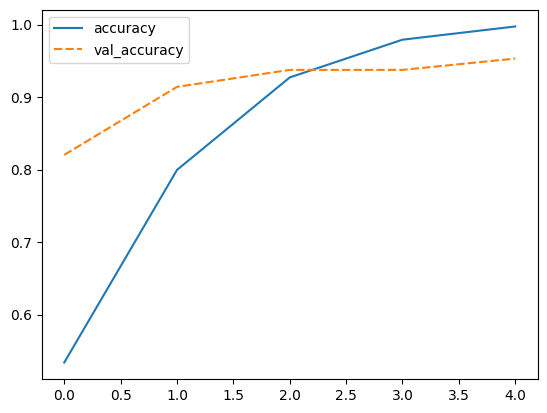

In [23]:
"""
同様に、正解率（accuracy, val_accuracy）の推移も可視化します。
"""
sns.lineplot(data=df[['accuracy', 'val_accuracy']])

In [ ]:
"""
損失関数と正解率の推移の曲線から、学習データ、バリデーションデータともに
良好な数値で安定しており、十分に学習できていると判断できます。
以上で、学習は完了です。
"""

In [24]:
"""
15 評価

次に、学習済み予測モデルの評価をします。
Sequentialクラスのevaluateメソッドを使って評価を実行できます。
この際に引数にはテストデータのジェネレータを指定します。
"""
model.evaluate(test_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step - accuracy: 0.8750 - loss: 0.3057


[0.3156920075416565, 0.8671875]

In [24]:
"""
テストデータによる評価結果は、
損失関数（loss）が約0.3057であり、正解率（accuracy）は約0.8750です。

この評価結果が十分であれば、次のステップに進みます。
そうでなければ、予測モデルの構造や損失関数、最適化手法、ハイパーパラメータなどを見直して、
再度学習をする必要があります。
"""

In [ ]:
"""
16 予測

最後に、実際に犬もしくは猫の画像を投入し、
正しく判定できるかを確認します。

予測は、以下の順で進めます。

・画像ファイルの取り込み
・画像ファイルの前処理
・予測
"""

In [ ]:
"""
1. 画像ファイルの取り込み

まずは、予測したい画像を取り込みます。
「unknown_cat.jpg」（リンクからダウンロード可）を未知の画像データとして利用してください。
https://drive.google.com/file/d/18Wv4ctEl9Y59RrdD-l4JGOJFjzXjtPKQ/view
ダウンロード後、Google Colaboratoryに「unknown_cat.jpg」をアップロードします。
"""

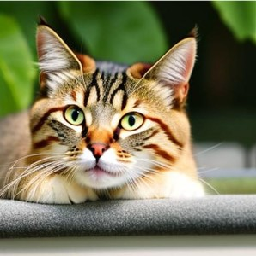

In [25]:
"""
次に、Kerasのpreprocessingモジュールのload_img関数をインポートし、画像を取り込みます。
target_sizeパラメータで、取り込み時の画像のサイズを指定できます。
ジェネレータ作成の際に設定したサイズに合わせ、縦256ピクセル×横256ピクセルを指定します。
"""
from tensorflow.keras.preprocessing.image import load_img
unknown_img = load_img('unknown_cat.jpg', target_size=(256, 256))
unknown_img

In [26]:
"""
2. 画像ファイルの前処理

次に画像ファイルの前処理を行います。
画像データをarray形式に変換し、
予測モデルのインプットデータの構造である
「任意のサンプル数×縦256ピクセル×横256ピクセル×3チャネル」の形状に揃えます。

その次に、ImageDataGeneratorのインスタンス作成時の設定と同様に、256で割ってスケーリングを行います。
"""
from tensorflow.keras.preprocessing.image import img_to_array

# array形式に変換
unknown_array = img_to_array(unknown_img)

# データ構造の変換
unknown_array = unknown_array.reshape((1, 256, 256, 3))

#スケーリング
unknown_array = unknown_array/255

In [27]:
"""
3. 予測

最後に、Sequentialクラスのpredictメソッドを利用して、取り込んだ画像データが、
犬・猫のどちらのカテゴリであるかの予測をします。
"""
model.predict(unknown_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


array([[1.0000000e+00, 6.1329643e-16]], dtype=float32)

In [ ]:
"""
ジェネレータ作成時に確認した通り、猫は数値ラベル0、犬は数値ラベル1で表現されます。
したがって、出力結果から、猫である確率がほぼ100%、犬である確率がほぼ0%であると予測できます。

VGG16を転移学習させ、犬と猫の画像を判定する流れは以上となります。
"""

In [29]:
"""
17 予測モデルの保存と読み込み
学習済みの予測モデルは、保存して、必要に応じて再利用可能です。
"""
model.save('my_model.keras')

In [32]:
"""
予測モデルの読み込み

load_model関数を使うと、保存した予測モデルを読み込み、再利用できます。
"""
from tensorflow.keras.models import load_model
loaded_model = load_model('my_model.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [33]:
"""
読み込んだモデルを利用して、先程犬猫判定した画像を、再度予測します。
"""
loaded_model.predict(unknown_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step


array([[1.0000000e+00, 6.1329643e-16]], dtype=float32)

In [ ]:
"""
読み込んだモデルでも、犬猫の画像判定が可能であることを確認できました。
"""